In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split  # 对数据集切分
from sklearn.metrics import r2_score
from sklearn import preprocessing
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression  # 多元线性回归算法

In [3]:
data = pd.read_csv('1F_SZ300.csv')  #读取数据集

In [4]:
#查看数据
data

,P1,P2,P3,P4,P5,P6,P7,target
0,0.0031,0.0160,0.0339,0.0328,0.0424,0.0243,0.8410,0.0564
1,0.0038,0.0112,0.0246,0.0185,0.0256,0.0164,0.7555,0.0294
2,0.0035,0.0100,0.0250,0.0233,0.0241,0.0204,0.6224,0.0324
3,0.0032,0.0094,0.0261,0.0138,0.0202,0.0227,0.8254,0.0184
4,0.0030,0.0089,0.0268,0.0092,0.0274,0.0143,0.8804,0.0128
...,...,...,...,...,...,...,...,...
2897,0.9891,0.4469,0.7746,0.0320,0.8551,0.9562,0.8982,0.0888
2898,0.9792,0.3084,0.7067,0.0200,0.7452,0.9620,0.8428,0.0510
2899,0.9968,0.3335,0.5972,0.0137,0.8627,0.9176,0.9456,0.0722
2900,0.9795,0.7115,0.7785,0.0110,0.7572,0.8324,0.9645,0.0469


In [5]:
#把数据转化为array
data.values

array([[0.0031, 0.016 , 0.0339, ..., 0.0243, 0.841 , 0.0564],
       [0.0038, 0.0112, 0.0246, ..., 0.0164, 0.7555, 0.0294],
       [0.0035, 0.01  , 0.025 , ..., 0.0204, 0.6224, 0.0324],
       ...,
       [0.9968, 0.3335, 0.5972, ..., 0.9176, 0.9456, 0.0722],
       [0.9795, 0.7115, 0.7785, ..., 0.8324, 0.9645, 0.0469],
       [0.9413, 0.833 , 0.8261, ..., 0.7858, 0.9399, 0.1365]])

In [6]:
data.values[:,0:7].shape

(2902, 7)

In [7]:
data.values[:,7:].shape

(2902, 1)

In [8]:
#把特征值和目标分开
x_data = data.values[:,0:7] #所有的特征变量
y_data = data.values[:,7:] #目标值

In [10]:
# 切分训练集，测试集
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, random_state=0, test_size=0.20)



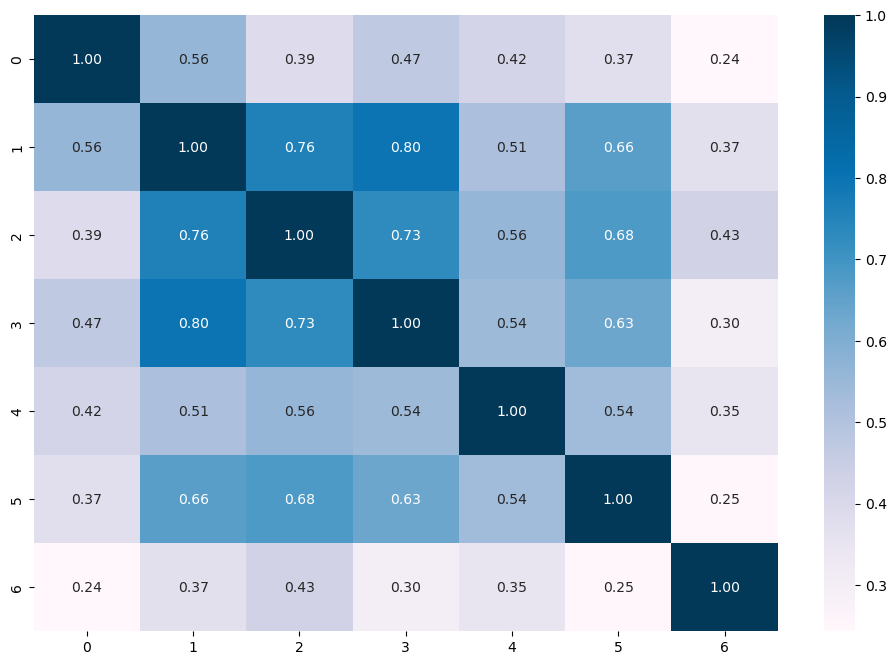

In [11]:
#热力图
plt.figure(figsize=(12,8))
data=pd.DataFrame(x_data)
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='PuBu')
plt.show()

In [12]:
### 数据标归一化处理
min_max_scaler = preprocessing.MinMaxScaler()  # 最值归一化
# 分别对训练集和测试集进行归一化处理
x_train = min_max_scaler.fit_transform(X_train)
x_test = min_max_scaler.fit_transform(X_test)
y_train = min_max_scaler.fit_transform(y_train.reshape(-1, 1))
y_test = min_max_scaler.fit_transform(y_test.reshape(-1, 1))

# 使用线性回归模型
lr = LinearRegression()
lr.fit(x_train, y_train)  # 传入数据进行训练

# 预测
predict = lr.predict(x_test)

# 使用R2_score评估模型
from sklearn.metrics import r2_score
score = r2_score(y_test, predict)
score

0.784427324350466

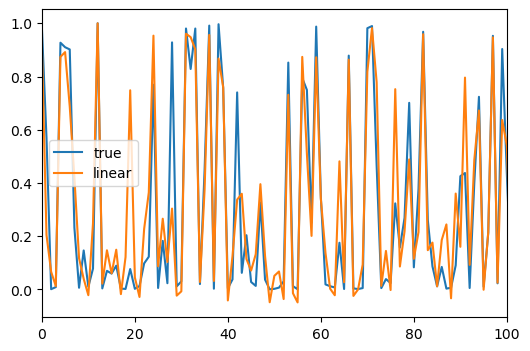

In [13]:
#图表展示t
plt.figure(figsize=(6,4))
plt.plot(y_test, label='true')
plt.plot(predict, label='linear')
plt.legend()
plt.xlim(0, 100)
plt.show()